### Mapa capacidad eólica

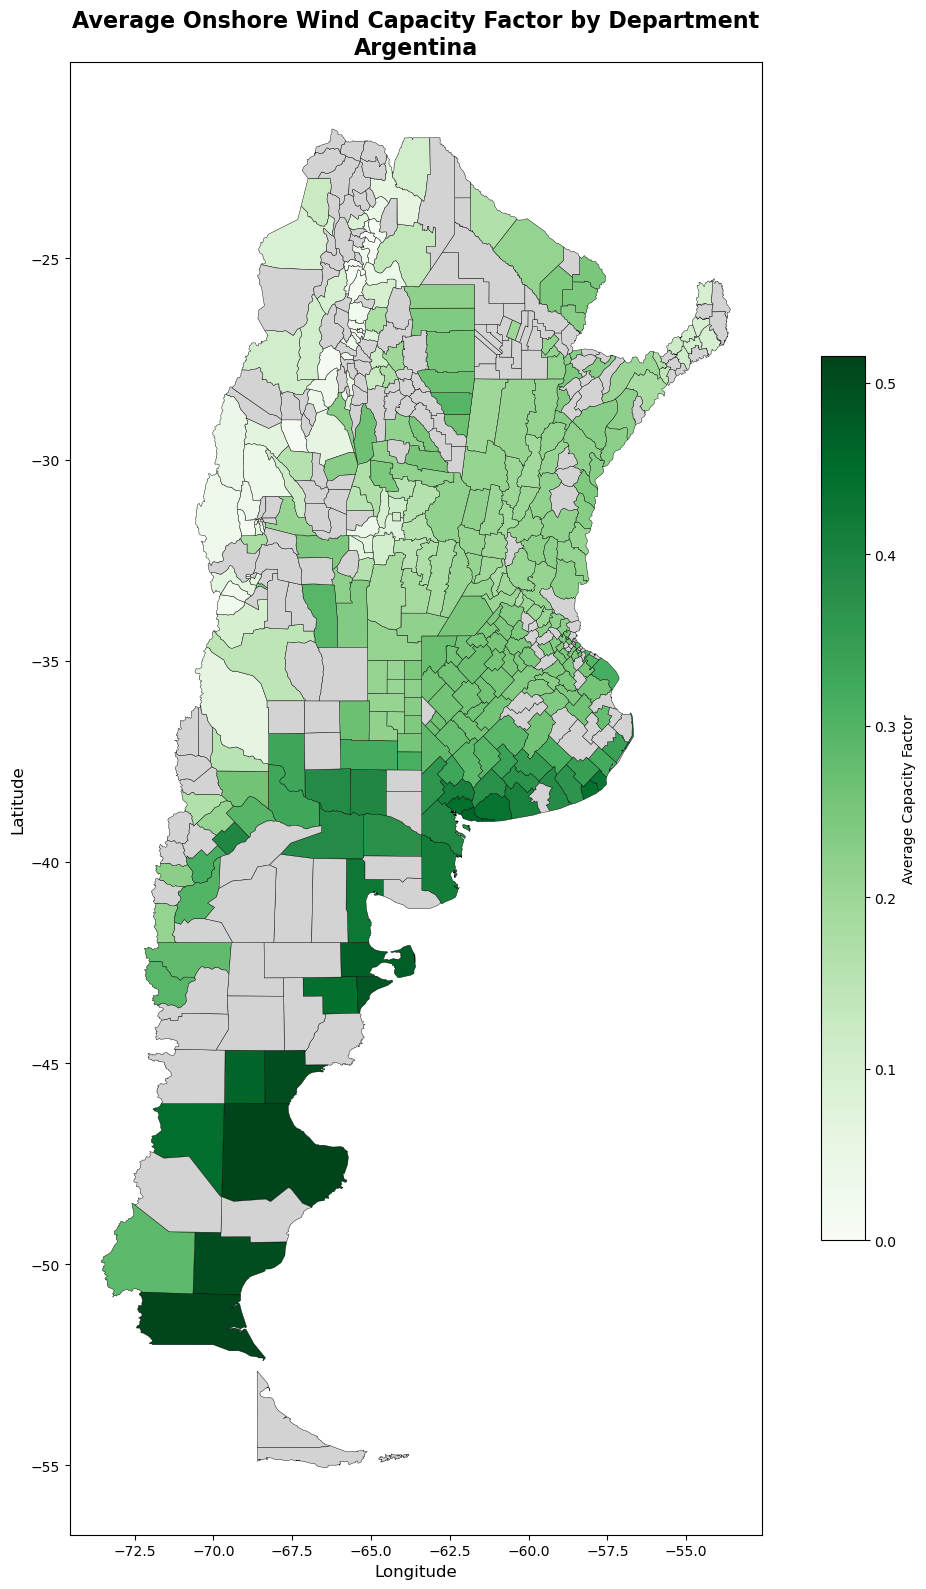

In [ ]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
ds = xr.open_dataset(renewable_profiles\profile_onwind.nc")
gdf = gpd.read_file(municipios.geojson")
mapping = pd.read_csv(bus_to_department_mapping.csv")

# Calculate average capacity factor over time for each bus
avg_cf = ds.mean(dim='time')
cf_var = list(ds.data_vars)[0]
avg_cf_values = avg_cf[cf_var].values

# Get bus names
coord_name = 'bus' if 'bus' in ds.coords else [c for c in ds.coords if c != 'time'][0]
buses = ds[coord_name].values

# Create dataframe with bus and capacity factors - convert bus to string
cf_df = pd.DataFrame({'bus': buses.astype(str), 'avg_cf': avg_cf_values})

# Convert mapping bus column to string as well
mapping['bus'] = mapping['bus'].astype(str)

# Merge with mapping to get departments
cf_df = cf_df.merge(mapping, on='bus', how='left')

# Calculate average capacity factor per department
dept_avg = cf_df.groupby('department')['avg_cf'].mean().reset_index()

# Merge with geodataframe
gdf = gdf.merge(dept_avg, left_on='GADM_ID', right_on='department', how='left')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 16))
gdf.plot(column='avg_cf', ax=ax, legend=True, cmap='Greens', 
         edgecolor='black', linewidth=0.3, 
         legend_kwds={'label': 'Average Capacity Factor', 'shrink': 0.6},
         missing_kwds={'color': 'lightgrey'})
ax.set_title('Average Onshore Wind Capacity Factor by Department\nArgentina', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.savefig('onwind_capacity_map.png', dpi=300, bbox_inches='tight')
plt.show()

### Capacidad eolica en el tiempo

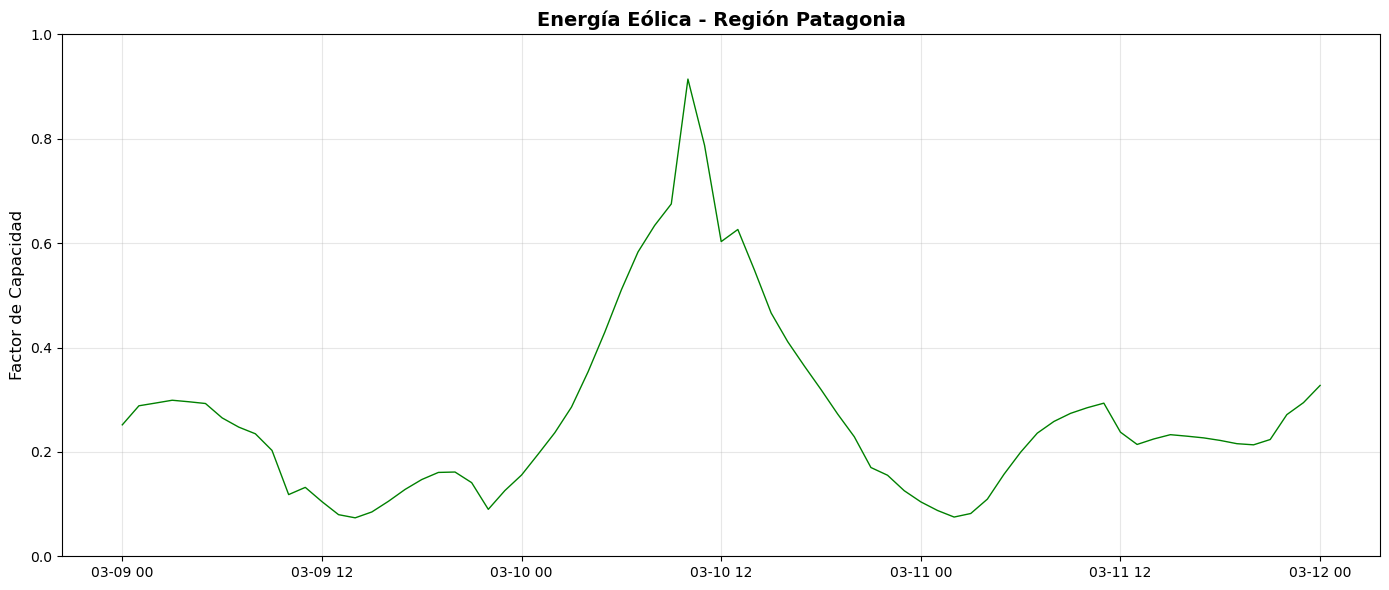

Average capacity factor: 0.269
Min: 0.074
Max: 0.914


In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
region = "BAS"  # Change this to any region name, or "" for total system
start = pd.Timestamp("2013-03-09 00:00:00")
end   = pd.Timestamp("2013-03-12 00:00:00")

# Load data
ds = xr.open_dataset(renewable_profiles\profile_onwind.nc")
mapping = pd.read_csv(bus_to_region_mapping.csv")

# Get time coordinate and bus coordinate names
time_coord = 'time' if 'time' in ds.coords else 'snapshots'
bus_coord = 'bus' if 'bus' in ds.coords else [c for c in ds.coords if c != time_coord][0]
cf_var = list(ds.data_vars)[0]

# Convert to dataframe for easier manipulation
df = ds[cf_var].to_dataframe().reset_index()

# Convert bus to string and merge with region mapping
df[bus_coord] = df[bus_coord].astype(str)
mapping['bus'] = mapping['bus'].astype(str)
df = df.merge(mapping, left_on=bus_coord, right_on='bus', how='left')

# Filter by region (if specified)
if region != "":
    df = df[df['region'] == region]
    title_suffix = f" - {region}"
else:
    title_suffix = " - Total System"

# Group by time and calculate mean capacity factor
df_time = df.groupby(time_coord)[cf_var].mean().reset_index()

# Filter by time window
df_time = df_time[(df_time[time_coord] >= start) & (df_time[time_coord] <= end)]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_time[time_coord], df_time[cf_var], linewidth=1, color='green')
ax.set_ylabel('Factor de Capacidad', fontsize=12)
ax.set_title(f'Energía Eólica - Región Patagonia', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Average capacity factor: {df_time[cf_var].mean():.3f}")
print(f"Min: {df_time[cf_var].min():.3f}")
print(f"Max: {df_time[cf_var].max():.3f}")

### Mapa capacidad solar

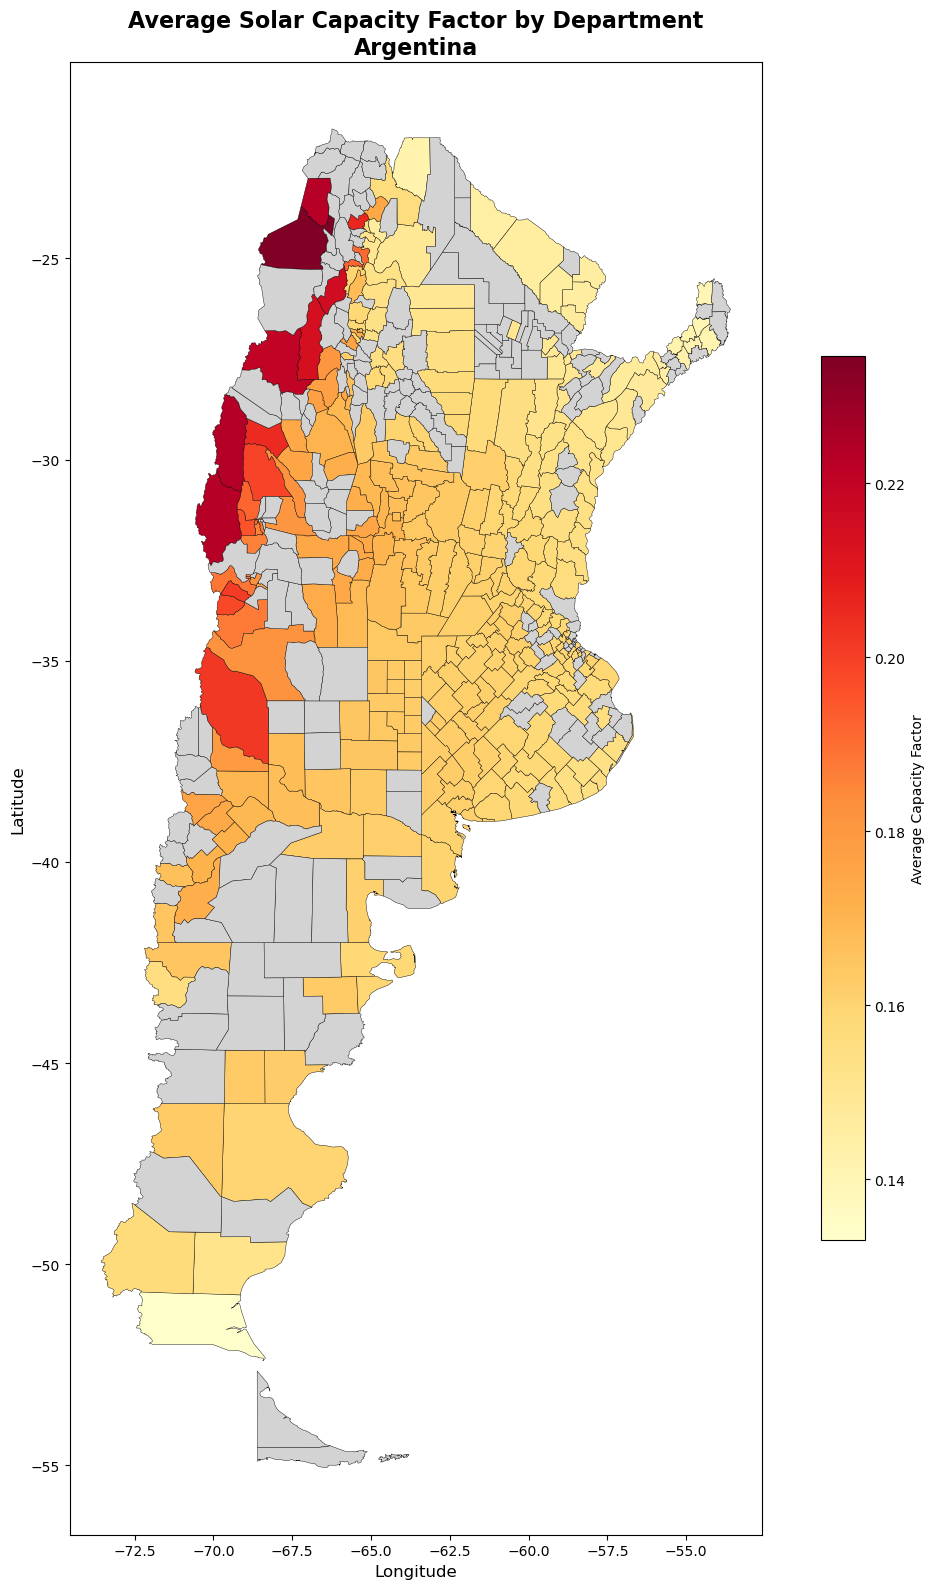

In [ ]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
ds = xr.open_dataset(renewable_profiles\profile_solar.nc")
gdf = gpd.read_file(municipios.geojson")
mapping = pd.read_csv(bus_to_department_mapping.csv")

# Calculate average capacity factor over time for each bus
avg_cf = ds.mean(dim='time')
cf_var = list(ds.data_vars)[0]
avg_cf_values = avg_cf[cf_var].values

# Get bus names
coord_name = 'bus' if 'bus' in ds.coords else [c for c in ds.coords if c != 'time'][0]
buses = ds[coord_name].values

# Create dataframe with bus and capacity factors - convert bus to string
cf_df = pd.DataFrame({'bus': buses.astype(str), 'avg_cf': avg_cf_values})

# Convert mapping bus column to string as well
mapping['bus'] = mapping['bus'].astype(str)

# Merge with mapping to get departments
cf_df = cf_df.merge(mapping, on='bus', how='left')

# Calculate average capacity factor per department
dept_avg = cf_df.groupby('department')['avg_cf'].mean().reset_index()

# Merge with geodataframe
gdf = gdf.merge(dept_avg, left_on='GADM_ID', right_on='department', how='left')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 16))
gdf.plot(column='avg_cf', ax=ax, legend=True, cmap='YlOrRd', 
         edgecolor='black', linewidth=0.3, 
         legend_kwds={'label': 'Average Capacity Factor', 'shrink': 0.6},
         missing_kwds={'color': 'lightgrey'})
ax.set_title('Average Solar Capacity Factor by Department\nArgentina', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.savefig('solar_capacity_map.png', dpi=300, bbox_inches='tight')
plt.show()

### Capacidad solar en el tiempo

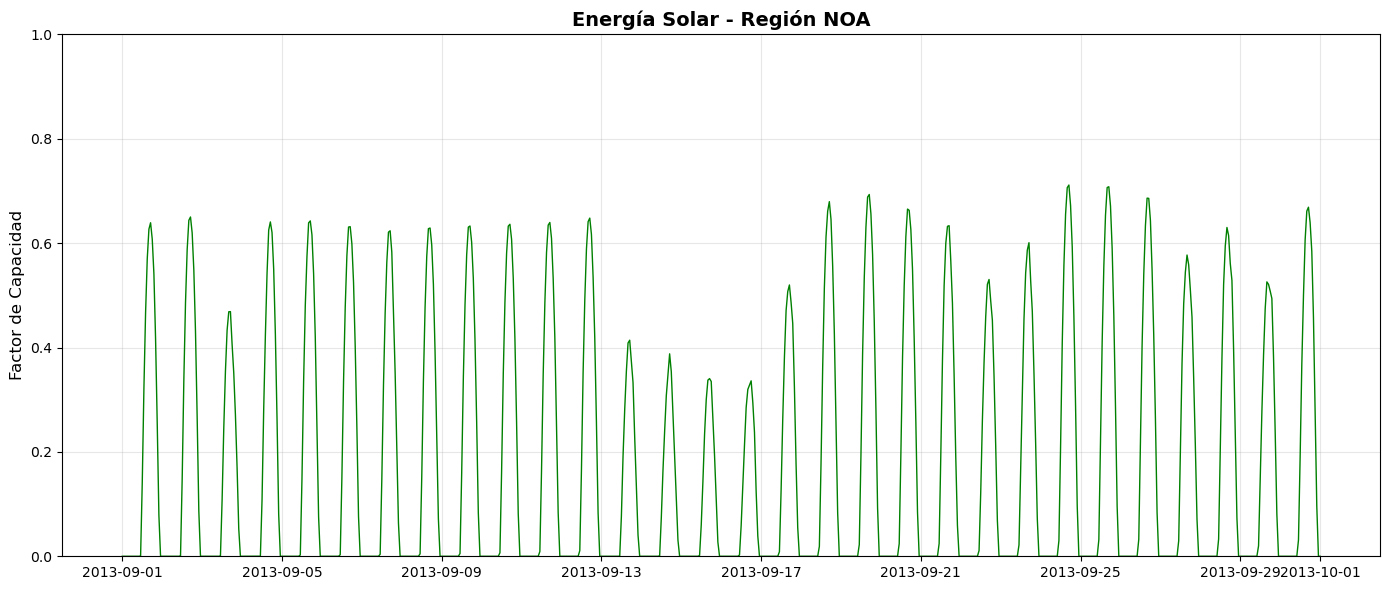

Average capacity factor: 0.181
Min: 0.000
Max: 0.711


In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
region = "NOA"  # Change this to any region name, or "" for total system
start = pd.Timestamp("2013-09-01 00:00:00")
end   = pd.Timestamp("2013-10-01 00:00:00")

# Load data
ds = xr.open_dataset(renewable_profiles\profile_solar.nc")
mapping = pd.read_csv(bus_to_region_mapping.csv")

# Get time coordinate and bus coordinate names
time_coord = 'time' if 'time' in ds.coords else 'snapshots'
bus_coord = 'bus' if 'bus' in ds.coords else [c for c in ds.coords if c != time_coord][0]
cf_var = list(ds.data_vars)[0]

# Convert to dataframe for easier manipulation
df = ds[cf_var].to_dataframe().reset_index()

# Convert bus to string and merge with region mapping
df[bus_coord] = df[bus_coord].astype(str)
mapping['bus'] = mapping['bus'].astype(str)
df = df.merge(mapping, left_on=bus_coord, right_on='bus', how='left')

# Filter by region (if specified)
if region != "":
    df = df[df['region'] == region]
    title_suffix = f" - {region}"
else:
    title_suffix = " - Total System"

# Group by time and calculate mean capacity factor
df_time = df.groupby(time_coord)[cf_var].mean().reset_index()

# Filter by time window
df_time = df_time[(df_time[time_coord] >= start) & (df_time[time_coord] <= end)]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_time[time_coord], df_time[cf_var], linewidth=1, color='green')
ax.set_ylabel('Factor de Capacidad', fontsize=12)
ax.set_title(f'Energía Solar - Región NOA', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Average capacity factor: {df_time[cf_var].mean():.3f}")
print(f"Min: {df_time[cf_var].min():.3f}")
print(f"Max: {df_time[cf_var].max():.3f}")